# Using the VanquishNeo Method Parser

## Imports

### External Packages

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
import sys
import anndata as ad
import zipfile
from pathlib import Path
import tempfile

### Internal Packages

In [ ]:
%load_ext autoreload
%autoreload 2

# Add the source path to Python path
import sys
import os
src_path = os.path.abspath(os.path.join(os.getcwd(), '../../src'))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import from the modules
from parsers.vneometh.vneo_method import VNeoMethod
from parsers.vneometh.lc_method_collection import VNeoMethodCollection
from parsers.timsmeth.ms_method import MicroTOFMethod
from parsers.timsmeth.ms_method_collection import MSMethodCollection
from parsers.diann.anndiannloader import DiannLoader
from parsers.diann.diann_collection import DiannCollection

# Integrator tools
from integrator.filters import filter_mask
from integrator.method_mapper import map_lcms_methods

print("All modules imported successfully!")

ModuleNotFoundError: No module named 'parsers'

## Setting Base Path

In [5]:
source = 'base'

In [6]:
if source == 'base':
    base = '/hpc/projects/mass_spec/eileenwang/'

## Loading LC Methods

#### LC Method Object

    Instantiate VNeoMethod Object

In [7]:
# Initialize VNeoMethod object with str path for a method file
lcmeth = VNeoMethod(f'{base}MethodOpt/LCMSmethodAnalysis/data/methods/LC/15p5m200nlv39.meth')

NameError: name 'VNeoMethod' is not defined

### Making LC Method Collection

#### Making collection object instance

In [26]:
lccollection = VNeoMethodCollection()

#### Adding in VNeo methods from a folder

In [28]:
lccollection.add_methods_from_folder(f'{base}MethodOpt/LCMSmethodAnalysis/data/methods/LC')

/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/src/parsers/vneometh/vneo_method.py:127: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gradient_df[col] = pd.to_numeric(gradient_df[col], errors='ignore')
/hpc/projects/mass_spec/eileenwang/MethodOpt/LCMSmethodAnalysis/src/parsers/vneometh/vneo_method.py:130: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  equil_df[col] = pd.to_numeric(equil_df[col], errors='ignore')


#### Using collection functions

**Viewing all methods loaded**

In [34]:
lccollection.methods.keys()

dict_keys(['18p6m200nlv34', '19m200nlv50', '18m200nlv48', 'Zebrawash8mA15', 'Blank650nlML5p5A15', '18m200nlv47', '18p6m200nlv38', '20m200nlML30mA15phospho4', '19m200nlv41', '19m200nlv45wash50B', '18p6m200nlv37', '19m200nlv43', '18p5m200nlv42', '22p65m200nlv49', '19m200nlv45wash650nl', '15p5m200nlv40', 'Blank650nlML7p5A15', '19m200nlv45FR150', '18p6m200nlv35', 'Blank650nlML2mA15', '23m200nlv52Zebrawash', '18p5m200nlv32', '21m200nlv51Zebrawash', '19m200nlv45', '18p6m200nlv36', '15p5m200nlv39', '18m200nlv46', '18p6m200nlv31', '18p5m200nlv33', '19m200nlv44'])

**Getting individual method object**

In [38]:
lccollection.methods['18p6m200nlv34']

##### Comparing Gradients

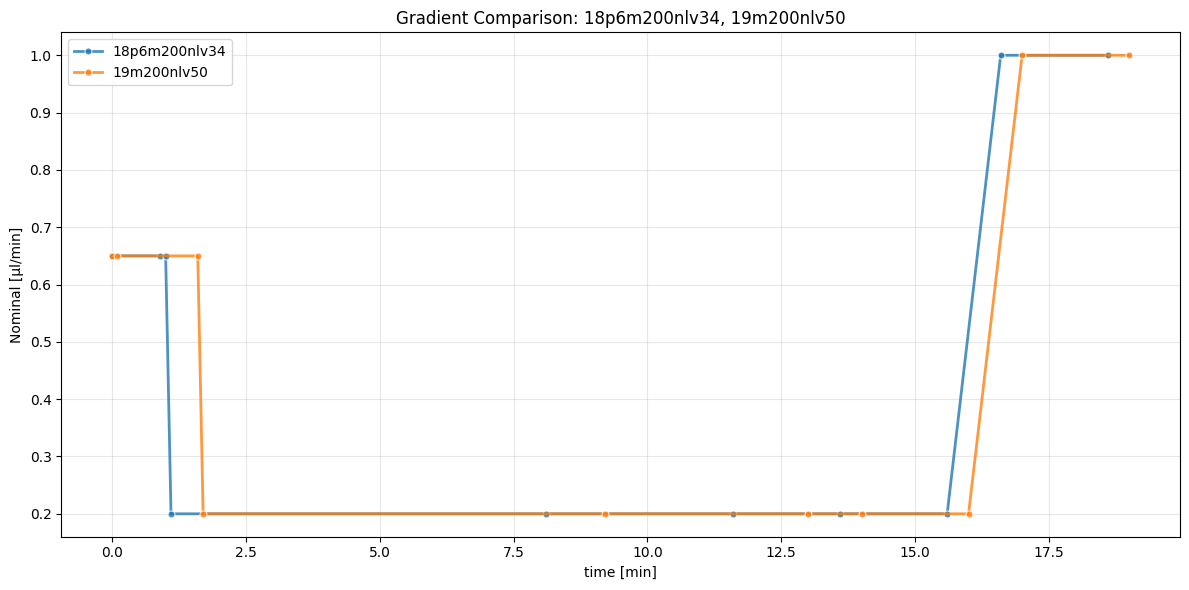

In [36]:
lccollection.plot_gradients(['18p6m200nlv34', '19m200nlv50'],
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], 
                        twin_axes=True , 
                        markers=True
);